In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense, Dropout , BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping , ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report,ConfusionMatrixDisplay


In [ ]:
#1 Load dataset
(X_train,y_train),(X_test,y_test)=mnist.load_data()
print("Training shape:",X_train.shape)
print("testing images:",X_test.shape)


Training shape: (60000, 28, 28)
testing images: (10000, 28, 28)


In [ ]:
#2 normalize images
X_train=X_train.astype('float32')/255.0
X_test=X_test.astype('float32')/255.0

In [ ]:
#3 flatten images
X_train=X_train.reshape(-1,784)
X_test=X_test.reshape(-1,784)

print("After flattening\n")
print(X_train.shape)
print(X_test.shape)

After flattening

(60000, 784)
(10000, 784)


In [ ]:
#4 MLP Architecture
model=Sequential()

model.add(Dense(512,activation='relu',input_shape=(784,)))
model.add(BatchNormalization())
model.add(Dropout(0.20))

model.add(Dense(256,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.30))


model.add(Dense(128,activation='relu'))
model.add(Dropout(0.20))

model.add(Dense(10,activation='softmax'))

In [ ]:
#5 compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#6 callbacks
earlystop=EarlyStopping(
    monitor='val_loss',
    patience=3,
    verbose=1,
    restore_best_weights=True
)
reduce_lr=ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)


In [ ]:
#7 model summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 570,506 (2.18 MB)

 Trainable params: 568,970 (2.17 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [ ]:
#8 train model
history=model.fit(
    X_train,y_train,
    batch_size=64,
    epochs=25,
    validation_split=0.2,
    callbacks=[earlystop,reduce_lr],
    verbose=1
)

Epoch 1/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.9080 - loss: 0.3014 - val_accuracy: 0.9632 - val_loss: 0.1195 - learning_rate: 0.0010
Epoch 2/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9530 - loss: 0.1573 - val_accuracy: 0.9712 - val_loss: 0.0994 - learning_rate: 0.0010
Epoch 3/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9632 - loss: 0.1218 - val_accuracy: 0.9747 - val_loss: 0.0855 - learning_rate: 0.0010
Epoch 4/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9674 - loss: 0.1051 - val_accuracy: 0.9714 - val_loss: 0.0971 - learning_rate: 0.0010
Epoch 5/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9725 - loss: 0.0894 - val_accuracy: 0.9767 - val_loss: 0.0805 - learning_rate: 0.0010
Epoch 6/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9740 - loss: 0.0830 - val_accuracy: 0.9758 - val_loss: 0.0869 - learning_rate: 0.0010
Epoch 7/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9762 - lo

In [ ]:
#9 evaluate
loss,accuracy=model.evaluate(X_test,y_test,verbose=0)
print("Test Loss:",loss)
print("Test Accuracy:",accuracy)

Test Loss: 0.060629602521657944
Test Accuracy: 0.9832000136375427


In [ ]:
#10 prediction
y_pred=model.predict(X_test)
y_pred=np.argmax(y_pred,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


[[ 972    1    0    0    1    1    2    1    1    1]
 [   0 1130    1    1    0    0    1    0    2    0]
 [   1    0 1019    2    1    0    0    6    3    0]
 [   0    0    2  995    0    1    0    4    3    5]
 [   0    0    5    0  958    0    3    1    0   15]
 [   2    0    0    6    1  875    3    0    4    1]
 [   2    2    0    1    4    3  945    0    1    0]
 [   0    0    7    1    0    0    0 1013    1    6]
 [   0    0    2    3    4    2    0    3  956    4]
 [   4    2    1    5    6    0    0    5    3  983]]


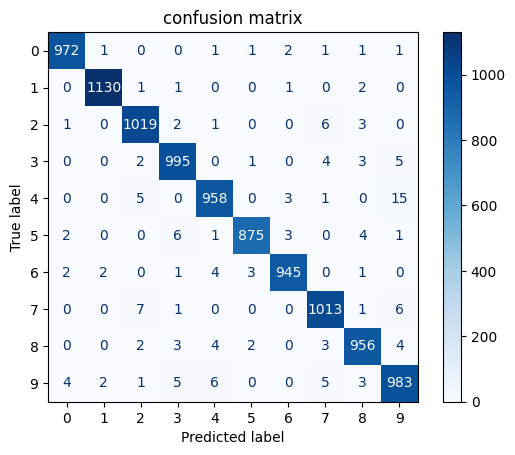

In [ ]:
#11 confusion matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('confusion matrix')
plt.show()

In [ ]:
#12 classification report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.98      0.99      0.99      1032
           3       0.98      0.99      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



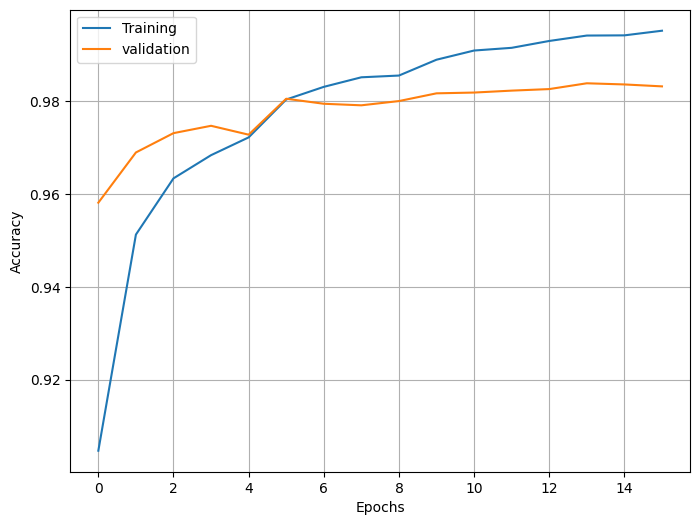

In [ ]:
#13 accuracy graph

plt.figure(figsize=(8,6))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Training','validation'])
plt.grid()
plt.show()


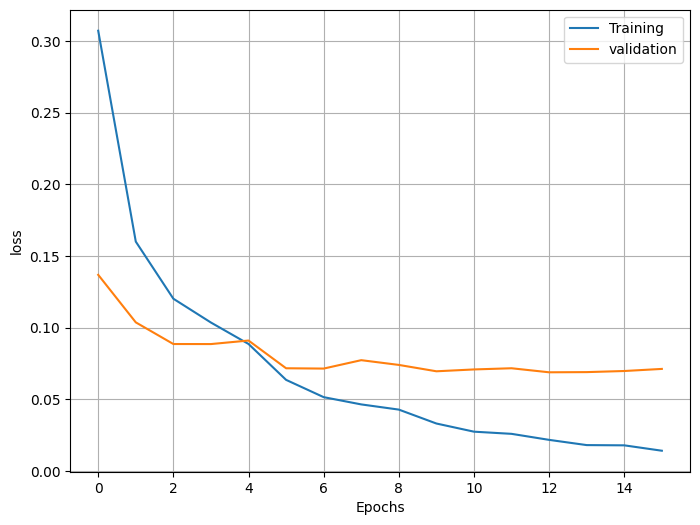

In [ ]:
#14 loss graph

plt.figure(figsize=(8,6))
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend(['Training','validation'])
plt.grid()
plt.show()

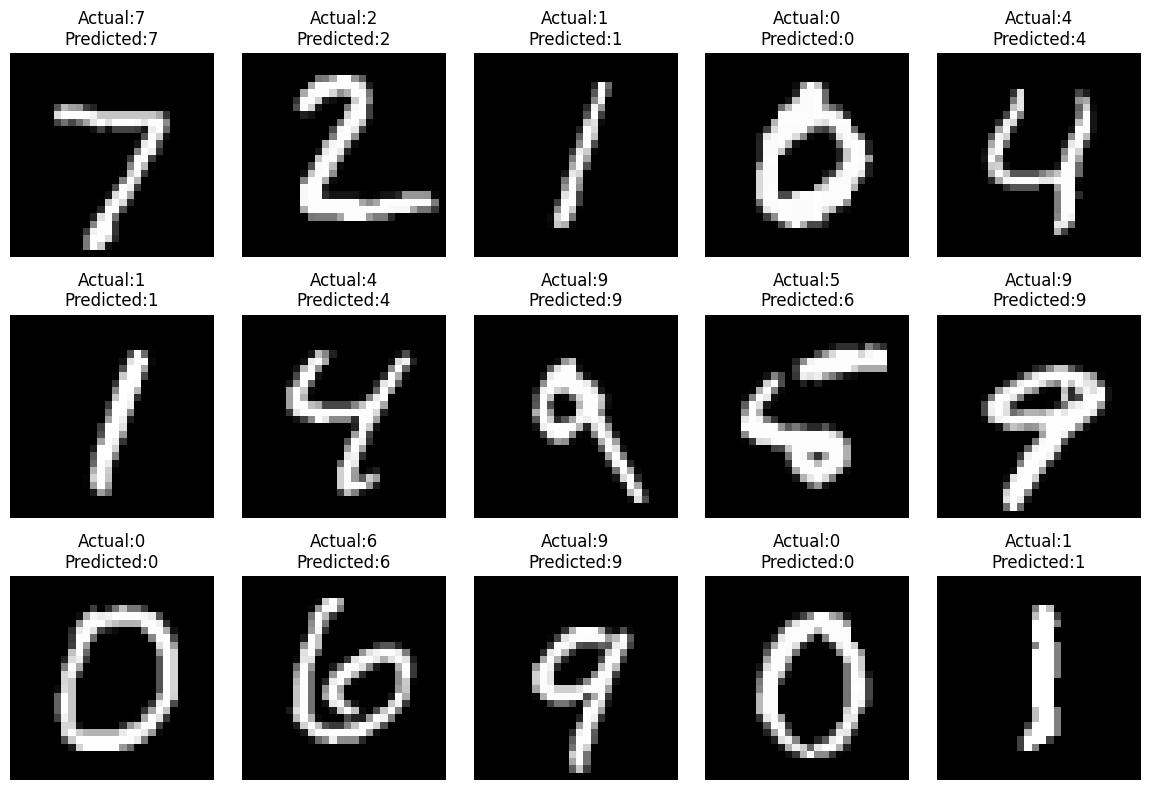

In [ ]:
#15 Display Predictions

plt.figure(figsize=(12,8))
for i in range(15):
  plt.subplot(3,5,i+1)
  plt.imshow(X_test[i].reshape(28,28),cmap='gray')
  plt.title(f"Actual:{y_test[i]}\nPredicted:{y_pred[i]}")
  plt.axis('off')
  plt.tight_layout()
plt.show()

# NEW DATASET - Dry Bean

In [ ]:
#1 load dataset
import pandas as pd
df = pd.read_csv("/content/Dry_Bean_Dataset.csv")

print(df.head())
print(df.shape)

    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272751  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0     0.913358      0.007332  

In [ ]:
#2 defining features
X = df.drop("Class", axis=1)
y = df["Class"]

In [ ]:
#3 normalizimg
encoder = LabelEncoder()
y = encoder.fit_transform(y)
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
#4 split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (10888, 16)
Testing Shape: (2723, 16)


In [ ]:
model = Sequential()

model.add(Dense(128, activation='tanh', input_shape=(16,)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(64, activation='tanh'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(32, activation='tanh'))
model.add(Dropout(0.2))

model.add(Dense(7, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#6 model compilation
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#7 callbacks
earlystop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,

)

In [ ]:
#8 model summary
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,511 (52.78 KB)

 Trainable params: 13,127 (51.28 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
#9 Train Model
history = model.fit(
    X_train,
    y_train,
    batch_size=64,
    epochs=30,
    validation_split=0.2,
    verbose=1,
    callbacks=[earlystop, reduce_lr]
)

Epoch 1/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7424 - loss: 0.7764 - val_accuracy: 0.8967 - val_loss: 0.3599 - learning_rate: 0.0010
Epoch 2/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8712 - loss: 0.4013 - val_accuracy: 0.9063 - val_loss: 0.2724 - learning_rate: 0.0010
Epoch 3/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8873 - loss: 0.3428 - val_accuracy: 0.9307 - val_loss: 0.2151 - learning_rate: 0.0010
Epoch 4/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8932 - loss: 0.3281 - val_accuracy: 0.9325 - val_loss: 0.2068 - learning_rate: 0.0010
Epoch 5/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8930 - loss: 0.3159 - val_accuracy: 0.9320 - val_loss: 0.2120 - learning_rate: 0.0010
Epoch 6/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8951 - loss: 0.3004 - val_accuracy: 0.9141 - val_loss: 0.2345 - learning_rate: 0.0010
Epoch 7/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8975 - loss: 0.2965 - 

In [ ]:
#10 evaluation
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

Test Loss: 0.21253259479999542
Test Accuracy: 0.922879159450531


In [ ]:
#11 predictions
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


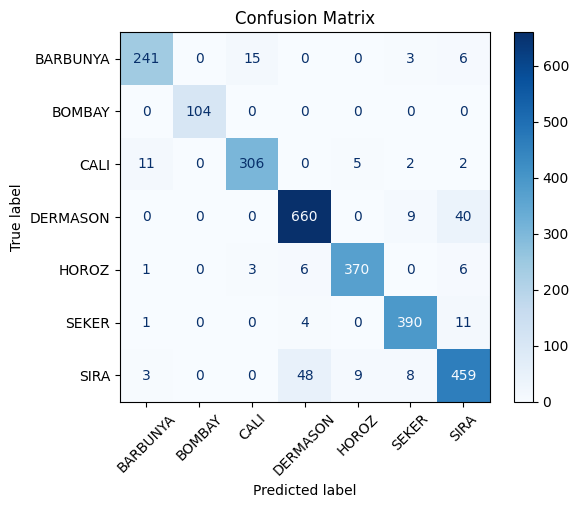

In [ ]:
#12 confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#13 classification report
print(classification_report(
    y_test,
    y_pred,

))

              precision    recall  f1-score   support

           0       0.94      0.91      0.92       265
           1       1.00      1.00      1.00       104
           2       0.94      0.94      0.94       326
           3       0.92      0.93      0.93       709
           4       0.96      0.96      0.96       386
           5       0.95      0.96      0.95       406
           6       0.88      0.87      0.87       527

    accuracy                           0.93      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.93      0.93      2723



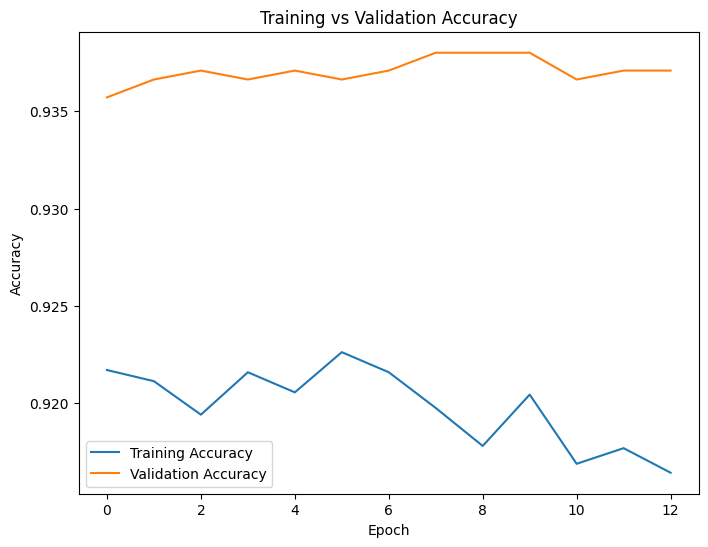

In [ ]:
#14 Accuracy graph
plt.figure(figsize=(8,6))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

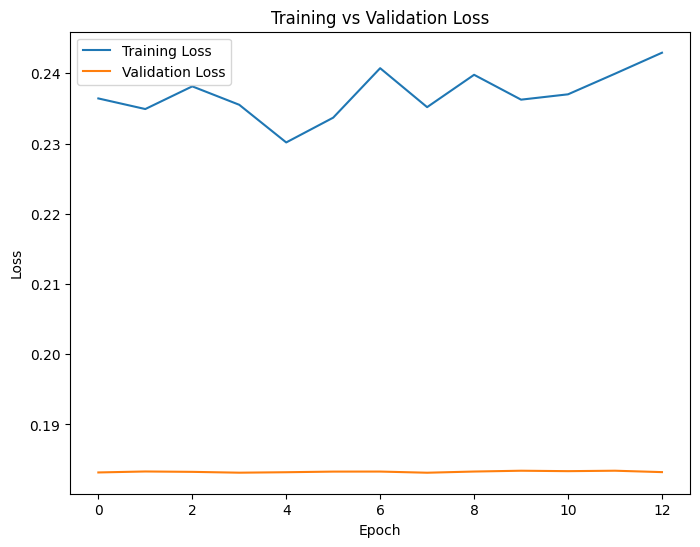

In [ ]:
#15 Loss Graph
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()